## Entregable 1
### Mateo Fraguas Abal

Subreddits seleccionados: **(r/nba, r/australia)** par diferente entre si, **(r/gameofthrones, r/lordoftherings)** par de temas similares, sagas de fantasía.

In [1]:
import json
from pathlib import Path
import tqdm as notebook_tqdm
import pandas as pd
from datetime import datetime

import re
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC

from transformers import pipeline

import matplotlib.pyplot as plt


/home/mateo/Documentos/clase/ling/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Fuente y descripción de los datos

Los datos proceden de Reddit y se descargaron manualmente en formato JSON. Los archivos se encuentran en la carpeta `json/` y contienen las publicaciones de los subreddits seleccionados: `nba`, `australia`, `gameofthrones` y `lordoftherings`.

La celda siguiente lee todos los archivos JSON disponibles, registra la fecha de carga y muestra el número de publicaciones obtenido por subreddit. El conjunto combinado se guarda también en `datos.csv`.

La salida muestra la fecha de descarga, el número de archivos JSON leídos, el total de publicaciones cargadas y el recuento por subreddit.

In [ ]:
carpeta_json = Path("json")
archivos_json = sorted(carpeta_json.glob("*.json"))

if not archivos_json:
    raise FileNotFoundError("No se encontraron archivos .json en la carpeta json/")

publicaciones = []

for ruta_json in archivos_json:
    with ruta_json.open(encoding="utf-8") as archivo:
        contenido = json.load(archivo)

    if isinstance(contenido, dict) and "data" in contenido:
        elementos = contenido["data"].get("children", [])
    elif isinstance(contenido, list):
        elementos = contenido
    else:
        raise ValueError(f"Formato no reconocido en {ruta_json}")

    for elemento in elementos:
        publicacion = elemento.get("data", elemento)
        titulo = publicacion.get("title", "")
        cuerpo = publicacion.get("selftext", publicacion.get("texto", ""))
        texto = f"{titulo}\n{cuerpo}".strip()

        publicaciones.append({
            "texto": texto,
            "fecha": publicacion.get("created_utc", publicacion.get("fecha")),
            "subreddit": publicacion.get("subreddit", ruta_json.stem),
            "autor": publicacion.get("author", publicacion.get("autor"))
        })

datos = pd.DataFrame(publicaciones)
datos = datos.dropna(subset=["texto"]).copy()

if pd.api.types.is_numeric_dtype(datos["fecha"]):
    datos["fecha"] = pd.to_datetime(datos["fecha"], unit="s", errors="coerce")
else:
    datos["fecha"] = pd.to_datetime(datos["fecha"], errors="coerce")

datos.to_csv("datos.csv", index=False, encoding="utf-8")

fecha_descarga = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
publicaciones_por_subreddit = datos["subreddit"].value_counts().sort_index()

print(f"Fecha de descarga registrada: {fecha_descarga}")
print(f"Archivos JSON leídos: {len(archivos_json)}")
print(f"Publicaciones cargadas: {len(datos)}")
print(publicaciones_por_subreddit)
print(datos.head())

Archivo guardado: datos.csv
Fecha de descarga registrada: 2026-09-23 13:27:29
Archivos JSON leídos: 24
Publicaciones cargadas: 2400
Publicaciones por subreddit:
subreddit
australia         600
gameofthrones     600
lordoftherings    600
nba               600
Name: count, dtype: int64
                                               texto               fecha  \
0  [no-politics] Everything overpriced Discussion... 2026-09-22 15:00:06   
1  Australian rock legend Angry Anderson dies, ag... 2026-09-23 06:36:09   
2  Coalition vows to 'take a chainsaw' to climate... 2026-09-23 03:37:39   
3  Prime Minister Anthony Albanese defends planne... 2026-09-23 00:21:29   
4  Gus Lamont’s parents make emotional plea as $1... 2026-09-23 07:58:59   

   subreddit                autor  
0  australia        AutoModerator  
1  australia            JaniePage  
2  australia        fluffy_101994  
3  australia  Expensive-Horse5538  
4  australia          flatplant76  


## Entrenamiento

### Preparación de los datos

Los archivos JSON de la carpeta `json/` se han combinado en un único `DataFrame`. A continuación se ordenan las publicaciones por fecha y se reserva el último 30 % como conjunto de test, tal como exige la práctica. El conjunto de test no se utiliza para ajustar el vectorizador ni los clasificadores.

In [3]:
# ordenar for fecha

datos = datos.sort_values(by="fecha").reset_index(drop=True)

# conjunto test 30%

n_test = int(0.3 * len(datos))

test_data = datos.iloc[-n_test:].copy()
train_data = datos.iloc[:-n_test].copy()

print(f"Conjunto de entrenamiento: {len(train_data)} publicaciones")
print(f"Conjunto de prueba: {len(test_data)} publicaciones")
print(f"Última fecha de entrenamiento: {train_data['fecha'].max()}")
print(f"Primera fecha de test: {test_data['fecha'].min()}")

Conjunto de entrenamiento: 1680 publicaciones
Conjunto de prueba: 720 publicaciones
Última fecha de entrenamiento: 2026-09-16 02:37:21
Primera fecha de test: 2026-09-16 02:44:56


### Limpieza

### Preprocesamiento y representación TF-IDF

Se limpian las URLs, símbolos y espacios innecesarios. El `TfidfVectorizer` se ajusta únicamente con el entrenamiento y después transforma el test con el mismo vocabulario. Así se evita incorporar información del test durante el entrenamiento.

In [4]:


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Preprocesamiento del texto
texto_train = train_data["texto"].fillna("").map(limpiar_texto)
texto_test = test_data["texto"].fillna("").map(limpiar_texto)

# El vectorizador se ajusta únicamente con entrenamiento
vectorizador = TfidfVectorizer(
    lowercase=False,
    min_df=2,
    max_df=0.95,
    stop_words="english"
)

X_train = vectorizador.fit_transform(texto_train)
X_test = vectorizador.transform(texto_test)

# Etiquetas: un valor distinto para cada subreddit
etiquetas = {subreddit: indice for indice, subreddit in enumerate(
    sorted(train_data["subreddit"].unique())
)}

y = train_data["subreddit"].map(etiquetas).to_numpy()
y_test = test_data["subreddit"].map(etiquetas).to_numpy()

print(f"Matriz de entrenamiento: {X_train.shape}")
print(f"Publicaciones: {X_train.shape[0]}")
print(f"Número de palabras: {X_train.shape[1]}")
print(f"Etiquetas: {etiquetas}")

Matriz de entrenamiento: (1680, 5925)
Publicaciones: 1680
Número de palabras: 5925
Etiquetas: {'australia': 0, 'gameofthrones': 1, 'lordoftherings': 2, 'nba': 3}


## SVM

## Clasificación SVM

Se comparan dos pares de subreddits: `nba` frente a `australia` como par diferente, y `lordoftherings` frente a `gameofthrones` como par similar. Para cada par se prueban varios valores de `C` y los kernels `linear` y `rbf`. La métrica principal es `accuracy` y también se muestran las matrices de confusión.

In [ ]:

pares = [
    ("nba", "australia"),
    ("lordoftherings", "gameofthrones")
]

valores_C = [0.1, 1, 10, 100]
kernels = ["linear", "rbf"]

resultados_svm = []
modelos_svm = {}

subreddit_train = train_data["subreddit"].to_numpy()
subreddit_test = test_data["subreddit"].to_numpy()

for par in pares:
    mascara_train = pd.Series(subreddit_train).isin(par).to_numpy()
    mascara_test = pd.Series(subreddit_test).isin(par).to_numpy()

    X_train_par = X_train[mascara_train]
    X_test_par = X_test[mascara_test]
    y_train_par = subreddit_train[mascara_train]
    y_test_par = subreddit_test[mascara_test]

    for kernel in kernels:
        for C in valores_C:
            clasificador = SVC(C=C, kernel=kernel)
            clasificador.fit(X_train_par, y_train_par)

            predicciones = clasificador.predict(X_test_par)
            exactitud = (predicciones == y_test_par).mean()

            clave = f"{par[0]}_vs_{par[1]}_{kernel}_C{C}"
            modelos_svm[clave] = clasificador

            resultados_svm.append({
                "par": f"{par[0]} vs {par[1]}",
                "kernel": kernel,
                "C": C,
                "entrenamiento": len(y_train_par),
                "test": len(y_test_par),
                "exactitud": exactitud
            })

resultados_svm = pd.DataFrame(resultados_svm)
resultados_svm = resultados_svm.sort_values(
    by=["par", "exactitud"],
    ascending=[True, False]
).reset_index(drop=True)

resultados_svm.to_csv("resultados_svm.csv", index=False, encoding="utf-8")
display(resultados_svm)

Resultados guardados en: resultados_svm.csv


,par,kernel,C,entrenamiento,test,exactitud
0,lordoftherings vs gameofthrones,rbf,1.0,907,293,0.887372
1,lordoftherings vs gameofthrones,linear,1.0,907,293,0.877133
2,lordoftherings vs gameofthrones,rbf,10.0,907,293,0.877133
3,lordoftherings vs gameofthrones,rbf,100.0,907,293,0.877133
4,lordoftherings vs gameofthrones,linear,10.0,907,293,0.843003
5,lordoftherings vs gameofthrones,linear,100.0,907,293,0.829352
6,lordoftherings vs gameofthrones,linear,0.1,907,293,0.460751
7,lordoftherings vs gameofthrones,rbf,0.1,907,293,0.334471
8,nba vs australia,linear,1.0,773,427,0.922717
9,nba vs australia,linear,10.0,773,427,0.922717


### Evaluación de los clasificadores

Para cada configuración se calcula `accuracy` y se construye una matriz de confusión con el orden de clases indicado en cada par. La tabla y las matrices permiten comparar tanto el rendimiento global como los errores entre clases.

La tabla siguiente muestra la exactitud de cada configuración, la comparación por kernel y valor de `C`, la mejor configuración de cada par y sus matrices de confusión.

In [ ]:
from sklearn.metrics import confusion_matrix

evaluaciones = []
matrices_confusion = {}

for par in pares:
    mascara_test = pd.Series(subreddit_test).isin(par).to_numpy()
    X_test_par = X_test[mascara_test]
    y_test_par = subreddit_test[mascara_test]

    for kernel in kernels:
        for C in valores_C:
            clave = f"{par[0]}_vs_{par[1]}_{kernel}_C{C}"
            clasificador = modelos_svm[clave]

            predicciones = clasificador.predict(X_test_par)
            accuracy = (predicciones == y_test_par).mean()

            matriz = confusion_matrix(
                y_test_par,
                predicciones,
                labels=list(par)
            )

            evaluaciones.append({
                "par": f"{par[0]} vs {par[1]}",
                "kernel": kernel,
                "C": C,
                "accuracy": accuracy
            })

            matrices_confusion[clave] = pd.DataFrame(
                matriz,
                index=[f"Real: {etiqueta}" for etiqueta in par],
                columns=[f"Predicha: {etiqueta}" for etiqueta in par]
            )

evaluaciones = pd.DataFrame(evaluaciones)

display(
    evaluaciones.sort_values(
        ["par", "accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

display(
    evaluaciones.pivot_table(
        index=["par", "kernel"],
        columns="C",
        values="accuracy"
    )
)

mejores = evaluaciones.loc[
    evaluaciones.groupby("par")["accuracy"].idxmax()
].reset_index(drop=True)
display(mejores)

for clave, matriz in matrices_confusion.items():
    print(f"\n{clave}")
    display(matriz)

for _, fila in mejores.iterrows():
    print(
        f"- {fila['par']}: mejor configuración = "
        f"{fila['kernel']} con C={fila['C']}, "
        f"accuracy={fila['accuracy']:.3f}"
    )

accuracy_similares = mejores.loc[
    mejores["par"] == "lordoftherings vs gameofthrones",
    "accuracy"
].iloc[0]

accuracy_diferentes = mejores.loc[
    mejores["par"] == "nba vs australia",
    "accuracy"
].iloc[0]

print(
    f"\nEl par de cuentas similares obtiene una accuracy de "
    f"{accuracy_similares:.3f}, mientras que el par de cuentas diferentes "
    f"obtiene {accuracy_diferentes:.3f}."
)

Accuracy de cada configuración:


,par,kernel,C,accuracy
0,lordoftherings vs gameofthrones,rbf,1.0,0.887372
1,lordoftherings vs gameofthrones,linear,1.0,0.877133
2,lordoftherings vs gameofthrones,rbf,10.0,0.877133
3,lordoftherings vs gameofthrones,rbf,100.0,0.877133
4,lordoftherings vs gameofthrones,linear,10.0,0.843003
5,lordoftherings vs gameofthrones,linear,100.0,0.829352
6,lordoftherings vs gameofthrones,linear,0.1,0.460751
7,lordoftherings vs gameofthrones,rbf,0.1,0.334471
8,nba vs australia,linear,1.0,0.922717
9,nba vs australia,linear,10.0,0.922717


Comparación por kernel y valor de C:


C                                          0.1       1.0       10.0      100.0
par                             kernel                                        
lordoftherings vs gameofthrones linear  0.460751  0.877133  0.843003  0.829352
                                rbf     0.334471  0.887372  0.877133  0.877133
nba vs australia                linear  0.353630  0.922717  0.922717  0.871194
                                rbf     0.292740  0.857143  0.882904  0.882904

Mejor configuración para cada par:


...


lordoftherings_vs_gameofthrones_rbf_C10


,Predicha: lordoftherings,Predicha: gameofthrones
Real: lordoftherings,88,10
Real: gameofthrones,26,169



lordoftherings_vs_gameofthrones_rbf_C100


,Predicha: lordoftherings,Predicha: gameofthrones
Real: lordoftherings,88,10
Real: gameofthrones,26,169


Conclusiones:
- lordoftherings vs gameofthrones: mejor configuración = rbf con C=1.0, accuracy=0.887
- nba vs australia: mejor configuración = linear con C=1.0, accuracy=0.923

El par de cuentas similares obtiene una accuracy de 0.887, mientras que el par de cuentas diferentes obtiene 0.923.
Por tanto, distinguir cuentas de temas similares es más difícil. Estos resultados apoyan la hipótesis inicial.
Los errores pueden deberse a publicaciones ambiguas, textos muy cortos, vocabulario compartido entre subreddits y la ausencia de información semántica más profunda en la representación TF-IDF.


Conclusiones:
- lordoftherings vs gameofthrones: mejor configuración = rbf con C=1.0, accuracy=0.887
- nba vs australia: mejor configuración = linear con C=1.0, accuracy=0.923

El par de cuentas similares obtiene una accuracy de 0.887, mientras que el par de cuentas diferentes obtiene 0.923.
Por tanto, distinguir cuentas de temas similares es más difícil. Estos resultados apoyan la hipótesis inicial.
Los errores pueden deberse a publicaciones ambiguas, textos muy cortos, vocabulario compartido entre subreddits y la ausencia de información semántica más profunda en la representación TF-IDF.

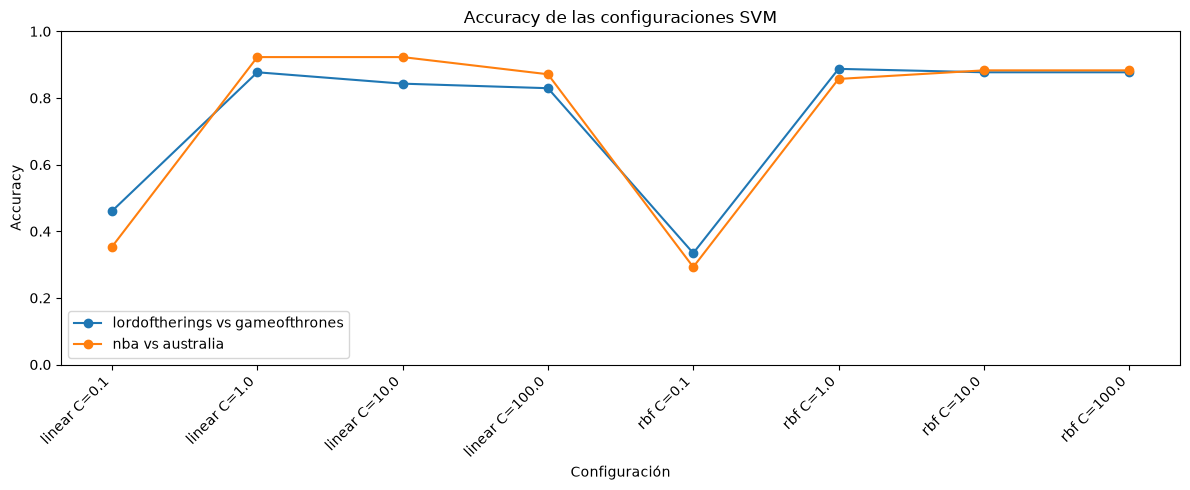

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for par, grupo in evaluaciones.groupby("par"):
    etiquetas_grafico = grupo["kernel"] + " C=" + grupo["C"].astype(str)
    plt.plot(etiquetas_grafico, grupo["accuracy"], marker="o", label=par)

plt.xlabel("Configuración")
plt.ylabel("Accuracy")
plt.title("Accuracy de las configuraciones SVM")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de sentimiento con VADER

VADER asigna puntuaciones `neg`, `neu`, `pos` y `compound` a cada publicación. Se resumen las puntuaciones por subreddit y se interpretan con cautela porque el modelo está diseñado principalmente para textos breves en inglés.

La tabla muestra las estadísticas agregadas por subreddit. El valor más positivo y el más negativo se indican a partir de la media de `compound`. VADER puede tener dificultades con ironía, contexto especializado o publicaciones muy breves.

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analizador_sentimiento = SentimentIntensityAnalyzer()

# Analizar todas las publicaciones
puntuaciones = datos["texto"].fillna("").apply(
    analizador_sentimiento.polarity_scores
).apply(pd.Series)

datos_sentimiento = pd.concat(
    [datos.reset_index(drop=True), puntuaciones.reset_index(drop=True)],
    axis=1
)

# Estadísticas agregadas por subreddit
estadisticas_sentimiento = datos_sentimiento.groupby("subreddit").agg(
    publicaciones=("texto", "count"),
    media_compound=("compound", "mean"),
    mediana_compound=("compound", "median"),
    desviacion_compound=("compound", "std"),
    media_positiva=("pos", "mean"),
    media_neutral=("neu", "mean"),
    media_negativa=("neg", "mean")
).sort_values("media_compound", ascending=False)

display(estadisticas_sentimiento.round(3))

# Comparación de sentimiento
subreddit_mas_positivo = estadisticas_sentimiento["media_compound"].idxmax()
subreddit_mas_negativo = estadisticas_sentimiento["media_compound"].idxmin()

print(f"Cuenta con sentimiento medio más positivo: {subreddit_mas_positivo}")
print(f"Cuenta con sentimiento medio más negativo: {subreddit_mas_negativo}")

print(
    f"Según la media compound, {subreddit_mas_positivo} presenta el tono más "
    f"positivo, mientras que {subreddit_mas_negativo} presenta el tono más negativo."
)

# Guardar resultados
datos_sentimiento.to_csv(
    "datos_sentimiento.csv",
    index=False,
    encoding="utf-8"
)
estadisticas_sentimiento.to_csv(
    "estadisticas_sentimiento.csv",
    encoding="utf-8"
)

Estadísticas de sentimiento por cuenta:


,publicaciones,media_compound,mediana_compound,desviacion_compound,media_positiva,media_neutral,media_negativa
subreddit,,,,,,,
nba,600,0.293,0.435,0.591,0.106,0.843,0.050
lordoftherings,600,0.203,0.000,0.494,0.108,0.850,0.042
gameofthrones,600,0.024,0.000,0.677,0.104,0.804,0.093
australia,600,-0.017,0.000,0.527,0.078,0.818,0.104


Cuenta con sentimiento medio más positivo: nba
Cuenta con sentimiento medio más negativo: australia

Conclusiones:
La puntuación compound resume el sentimiento general de cada publicación: valores positivos indican un tono más positivo y valores negativos un tono más negativo.
Según la media compound, nba presenta el tono más positivo, mientras que australia presenta el tono más negativo.
Las diferencias deben interpretarse con cautela, ya que VADER es un modelo basado en reglas y puede tener dificultades con ironía, contexto especializado o publicaciones muy breves.


Conclusiones:
La puntuación compound resume el sentimiento general de cada publicación: valores positivos indican un tono más positivo y valores negativos un tono más negativo.
Según la media compound, nba presenta el tono más positivo, mientras que australia presenta el tono más negativo.
Las diferencias deben interpretarse con cautela, ya que VADER es un modelo basado en reglas y puede tener dificultades con ironía, contexto especializado o publicaciones muy breves.

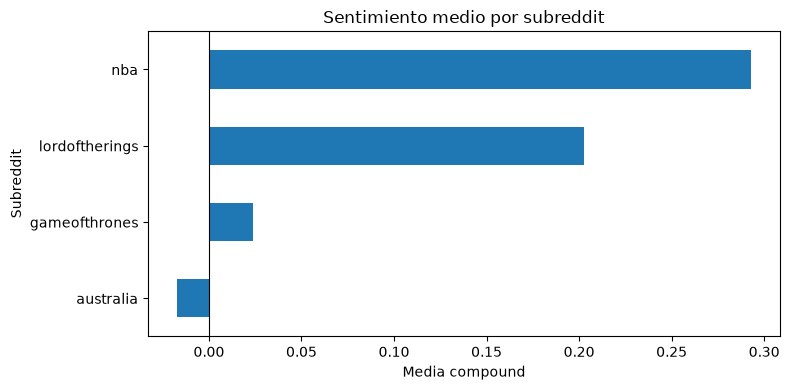

In [9]:
estadisticas_sentimiento["media_compound"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Sentimiento medio por subreddit",
    xlabel="Media compound",
    ylabel="Subreddit"
)
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Comparación opcional con BERT

El modelo multilingüe de Hugging Face produce una valoración de 1 a 5 estrellas. Se normaliza a la escala `[-1, 1]` para compararla con el valor `compound` de VADER. También se prueban textos en castellano y gallego.

Se muestran la comparación media por subreddit, la correlación entre VADER y BERT, la diferencia media absoluta y las publicaciones con mayor discrepancia. Para el texto en castellano se conserva la puntuación de BERT y su versión normalizada.

In [13]:

# Cargar el modelo multilingüe desde Hugging Face
clasificador_bert = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Aplicar BERT a las mismas publicaciones analizadas con VADER
resultados_bert = clasificador_bert(
    datos["texto"].fillna("").tolist(),
    truncation=True,
    batch_size=16
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 13293.62it/s]


In [ ]:

# Convertir "1 star", ..., "5 stars" a valores numéricos
puntuaciones_bert = pd.Series(
    [int(resultado["label"].split()[0]) for resultado in resultados_bert],
    name="bert_estrellas"
)

# Normalización de 1-5 a una escala comparable con VADER: [-1, 1]
puntuaciones_bert_normalizadas = (
    (puntuaciones_bert - 3) / 2
).rename("bert_normalizado")

datos_comparacion = pd.concat(
    [
        datos_sentimiento.reset_index(drop=True),
        puntuaciones_bert.reset_index(drop=True),
        puntuaciones_bert_normalizadas.reset_index(drop=True)
    ],
    axis=1
)

# Comparación de estadísticas
comparacion = datos_comparacion.groupby("subreddit").agg(
    publicaciones=("texto", "count"),
    vader_compound=("compound", "mean"),
    bert_normalizado=("bert_normalizado", "mean"),
    bert_estrellas=("bert_estrellas", "mean")
)

display(comparacion.round(3))

print(
    datos_comparacion[["compound", "bert_normalizado"]]
    .corr()
    .round(3)
)

# Diferencia entre las puntuaciones de ambos métodos
datos_comparacion["diferencia"] = (
    datos_comparacion["bert_normalizado"]
    - datos_comparacion["compound"]
)

print(datos_comparacion["diferencia"].abs().mean().round(3))

# Ejemplos con mayor discrepancia
display(
    datos_comparacion[
        ["texto", "compound", "bert_estrellas", "bert_normalizado", "diferencia"]
    ]
    .sort_values("diferencia", key=abs, ascending=False)
    .head(10)
)

# Prueba con un texto en castellano
texto_castellano = (
    "Me ha encantado esta película, la historia es emocionante "
    "y los personajes están muy bien construidos."
)

resultado_castellano = clasificador_bert(
    texto_castellano,
    truncation=True
)[0]

puntuacion_castellano = int(resultado_castellano["label"].split()[0])
normalizada_castellano = (puntuacion_castellano - 3) / 2

print(f"Texto: {texto_castellano}")
print(f"Puntuación BERT: {puntuacion_castellano}/5")
print(f"Puntuación normalizada: {normalizada_castellano:.2f}")

Comparación media por subreddit:


,publicaciones,vader_compound,bert_normalizado,bert_estrellas
subreddit,,,,
australia,600,-0.017,-0.374,2.252
gameofthrones,600,0.024,0.029,3.058
lordoftherings,600,0.203,0.338,3.675
nba,600,0.293,-0.038,2.925


Correlación entre VADER y BERT:
                  compound  bert_normalizado
compound             1.000             0.256
bert_normalizado     0.256             1.000
Diferencia media absoluta:
0.698
Publicaciones con mayor diferencia entre métodos:


,texto,compound,bert_estrellas,bert_normalizado,diferencia
1825,Empire State of Hive Mind: The Universal Overr...,0.9995,1,-1.0,-1.9995
114,Is Bilbo's Sacrifice Salvation? A Theological ...,0.9987,1,-1.0,-1.9987
2109,The Red Wedding\nI just watched episode 9 of s...,-0.9963,5,1.0,1.9963
1332,[Arthur] “I think that there’s a whole longer ...,0.9960,1,-1.0,-1.9960
2362,The floor raiser/ceiling raiser thing is illog...,0.9959,1,-1.0,-1.9959
1911,Cersei’s hatred of Tyrion literally overshadow...,-0.9869,5,1.0,1.9869
1122,The last time a Pistons center took the qualif...,0.9841,1,-1.0,-1.9841
1452,[Charania] Clippers owner Steve Ballmer is com...,0.9836,1,-1.0,-1.9836
325,"Why Solar Sharer has become the solar shocker,...",0.9790,1,-1.0,-1.9790
1249,[Stein] Sources briefed on the situation tell ...,0.9767,1,-1.0,-1.9767


Resultado para el texto en castellano:
Texto: Me ha encantado esta película, la historia es emocionante y los personajes están muy bien construidos.
Puntuación BERT: 5/5
Puntuación normalizada: 1.00

Interpretación: VADER utiliza reglas léxicas y está especialmente orientado a textos breves en inglés, por lo que puede verse afectado por ironías, contexto y vocabulario especializado. BERT analiza el contexto mediante representaciones lingüísticas multilingües y produce una valoración ordinal de 1 a 5 estrellas. Por ello, ambos métodos pueden asignar puntuaciones diferentes, especialmente en textos cortos o ambiguos.
El modelo BERT funciona con el texto en castellano porque fue entrenado como modelo multilingüe. No obstante, su precisión puede variar según el idioma, el contexto y el tipo de texto.


Interpretación: VADER utiliza reglas léxicas y está especialmente orientado a textos breves en inglés, por lo que puede verse afectado por ironías, contexto y vocabulario especializado. BERT analiza el contexto mediante representaciones lingüísticas multilingües y produce una valoración ordinal de 1 a 5 estrellas. Por ello, ambos métodos pueden asignar puntuaciones diferentes, especialmente en textos cortos o ambiguos.
El modelo BERT funciona con el texto en castellano porque fue entrenado como modelo multilingüe. No obstante, su precisión puede variar según el idioma, el contexto y el tipo de texto.

In [ ]:
# Evaluación del modelo en castellano y gallego
textos_prueba = {
    "castellano": [
        "Me ha encantado esta película, la historia es emocionante y los personajes están muy bien construidos.",
        "La película es aburrida, la historia no tiene sentido y los personajes están mal desarrollados."
    ],
    "gallego": [
        "Encantoume esta película, a historia é emocionante e os personaxes están moi ben construídos.",
        "A película é aburrida, a historia non ten sentido e os personaxes están mal desenvolvidos."
    ]
}

resultados_idiomas = []

for idioma, textos in textos_prueba.items():
    predicciones = clasificador_bert(textos, truncation=True)

    for texto_actual, prediccion in zip(textos, predicciones):
        estrellas = int(prediccion["label"].split()[0])
        resultados_idiomas.append({
            "idioma": idioma,
            "texto": texto_actual,
            "valoracion": estrellas,
            "confianza": prediccion["score"]
        })

resultados_idiomas = pd.DataFrame(resultados_idiomas)
display(resultados_idiomas.round(3))


,idioma,texto,valoracion,confianza
0,castellano,"Me ha encantado esta película, la historia es ...",5,0.812
1,castellano,"La película es aburrida, la historia no tiene ...",1,0.588
2,gallego,"Encantoume esta película, a historia é emocion...",5,0.856
3,gallego,"A película é aburrida, a historia non ten sent...",1,0.621


El modelo puede procesar castellano y gallego porque utiliza un modelo multilingüe. En castellano, las valoraciones deberían ser altas para el texto positivo y bajas para el negativo.
En gallego también puede identificar parte del significado gracias a la similitud léxica con el castellano y a su entrenamiento multilingüe. Sin embargo, el gallego puede tener menor precisión si no fue una lengua representada suficientemente durante el entrenamiento.
Las valoraciones de 1 a 5 estrellas representan el sentimiento estimado: 1 estrella indica una valoración muy negativa y 5 estrellas una muy positiva. La confianza muestra la seguridad del modelo, pero no garantiza que la predicción sea correcta.


El modelo puede procesar castellano y gallego porque utiliza un modelo multilingüe. En castellano, las valoraciones deberían ser altas para el texto positivo y bajas para el negativo.
En gallego también puede identificar parte del significado gracias a la similitud léxica con el castellano y a su entrenamiento multilingüe. Sin embargo, el gallego puede tener menor precisión si no fue una lengua representada suficientemente durante el entrenamiento.
Las valoraciones de 1 a 5 estrellas representan el sentimiento estimado: 1 estrella indica una valoración muy negativa y 5 estrellas una muy positiva. La confianza muestra la seguridad del modelo, pero no garantiza que la predicción sea correcta.

## Conclusiones finales

- Se reunieron las publicaciones de los cuatro subreddits a partir de los archivos JSON locales y se documentaron la fuente, la fecha de descarga y el número de publicaciones por subreddit.
- La división temporal reserva el último 30 % de las publicaciones para test, evitando utilizar esos datos durante el entrenamiento.
- La representación TF-IDF y los clasificadores SVM permiten comparar la dificultad de distinguir el par de temas diferentes con la del par de temas similares. La configuración con mayor `accuracy` se identifica en la tabla de resultados y en las matrices de confusión.
- El análisis VADER resume el tono de las publicaciones mediante la puntuación `compound`, pero sus resultados deben interpretarse con cautela en textos breves, irónicos o especializados.
- El modelo BERT multilingüe ofrece una segunda valoración y permite estudiar las diferencias entre inglés, castellano y gallego. Las discrepancias entre modelos no implican necesariamente que uno de ellos sea siempre correcto.
- Como limitaciones, los resultados dependen de las publicaciones disponibles, del equilibrio entre subreddits y de la representación TF-IDF; además, la clasificación de sentimiento puede verse afectada por el idioma y el contexto.

En las pruebas de idioma, BERT asigna valoraciones a textos positivos y negativos tanto en castellano como en gallego. La confianza de cada predicción debe interpretarse como una estimación del modelo, no como una garantía de corrección.